<h1 id="Lecture-8:-Regression,-loss-functions,-and-diagnostics">Lecture 8: Regression, loss functions, and diagnostics</h1><p>Regression estimates a conditional quantity. Under least squares, a linear regression estimates the conditional mean. A coefficient is a conditional association in the represented data. It is not, by itself, a causal effect.</p>

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

from ds301.paths import project_root
ROOT = project_root()
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#EE9B00", "#BB3E03", "#1D3557"
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams.update({"figure.dpi":120, "font.size":11, "axes.titleweight":"bold"})
data = pd.read_csv(ROOT / "data/delivery_regression.csv")

<h2 id="Begin-with-the-records">Begin with the records</h2><p>One row is one completed delivery. Inspect the measured inputs and outcome before fitting a line. The first plot will keep the raw points visible, then add a fitted equation so that the residuals have a concrete meaning.</p>

In [23]:
data[["distance_km", "items", "rain_mm", "delivery_minutes"]].head(10)

,distance_km,items,rain_mm,delivery_minutes
0,1.37,1,1.45,20.6
1,9.01,5,0.07,38.9
2,10.28,6,2.20,39.0
3,11.50,6,0.13,45.8
4,9.47,5,9.66,47.3
5,2.56,1,0.10,27.3
6,13.12,1,4.42,54.1
7,5.05,1,4.79,33.3
8,5.21,7,1.04,29.1
9,12.66,6,0.77,50.4


<h2 id="1.-Simple-least-squares-and-residuals">1. Simple least squares and residuals</h2><p>The fitted line $\hat y=\beta_0+\beta_1x$ minimizes the sum of squared residuals. A residual is the model's objection: $e_i=y_i-\hat y_i$.</p>

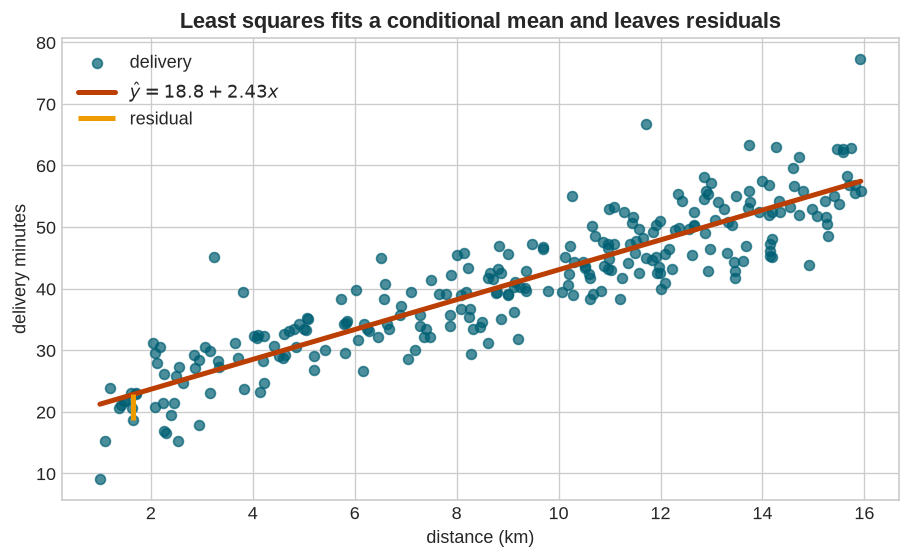

In [24]:
x = data[["distance_km"]]; y = data.delivery_minutes
simple = LinearRegression().fit(x, y); grid = np.linspace(x.min().iloc[0], x.max().iloc[0], 250)
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(x, y, c=TEAL, s=35, alpha=.7, label="delivery")
ax.plot(grid, simple.predict(pd.DataFrame({"distance_km": grid})), c=CORAL, lw=3, label=f"$\\hat y={simple.intercept_:.1f}+{simple.coef_[0]:.2f}x$")
sample = data.iloc[15]; predicted = simple.predict(pd.DataFrame({"distance_km": [sample.distance_km]}))[0]
ax.vlines(sample.distance_km, predicted, sample.delivery_minutes, color=GOLD, lw=3, label="residual")
ax.set(xlabel="distance (km)", ylabel="delivery minutes", title="Least squares fits a conditional mean and leaves residuals")
ax.legend(); plt.show()

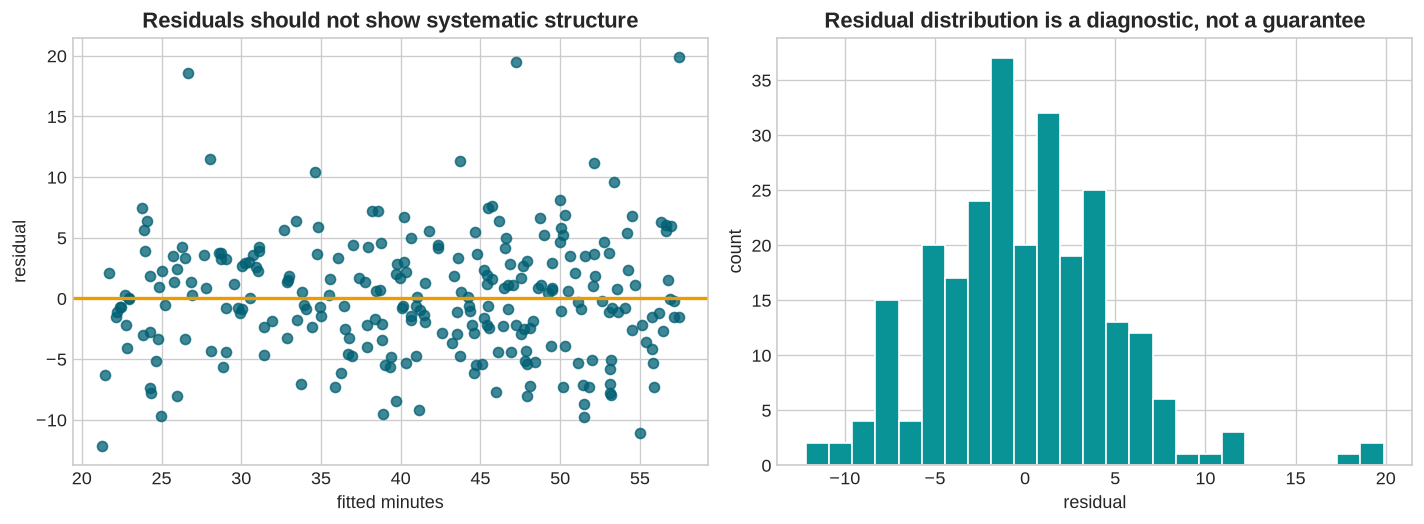

In [25]:
residual = y - simple.predict(x)
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(simple.predict(x), residual, c=TEAL, alpha=.75); axes[0].axhline(0,c=GOLD,lw=2)
axes[0].set(xlabel="fitted minutes", ylabel="residual", title="Residuals should not show systematic structure")
axes[1].hist(residual, bins=25, color=MINT, edgecolor="white")
axes[1].set(xlabel="residual", ylabel="count", title="Residual distribution is a diagnostic, not a guarantee")
plt.tight_layout()

<h2 id="2.-Different-losses-produce-different-equations">2. Different losses produce different equations</h2><p>MSE squares large errors. MAE gives each extra minute the same slope. With unusual deliveries, the chosen loss changes the fitted line.</p>

In [26]:
loss_rows = data[["distance_km", "delivery_minutes"]].copy()
loss_rows["baseline_prediction"] = y.median()
loss_rows["absolute_error"] = (loss_rows.delivery_minutes - loss_rows.baseline_prediction).abs()
loss_rows["squared_error"] = (loss_rows.delivery_minutes - loss_rows.baseline_prediction)**2
loss_rows.head(8)

,distance_km,delivery_minutes,baseline_prediction,absolute_error,squared_error
0,1.37,20.6,41.7,21.1,445.21
1,9.01,38.9,41.7,2.8,7.84
2,10.28,39.0,41.7,2.7,7.29
3,11.50,45.8,41.7,4.1,16.81
4,9.47,47.3,41.7,5.6,31.36
5,2.56,27.3,41.7,14.4,207.36
6,13.12,54.1,41.7,12.4,153.76
7,5.05,33.3,41.7,8.4,70.56


<p>The same raw delivery errors create both loss functions. The surfaces below show how the average of those errors changes as we try many intercept-and-slope pairs.</p>

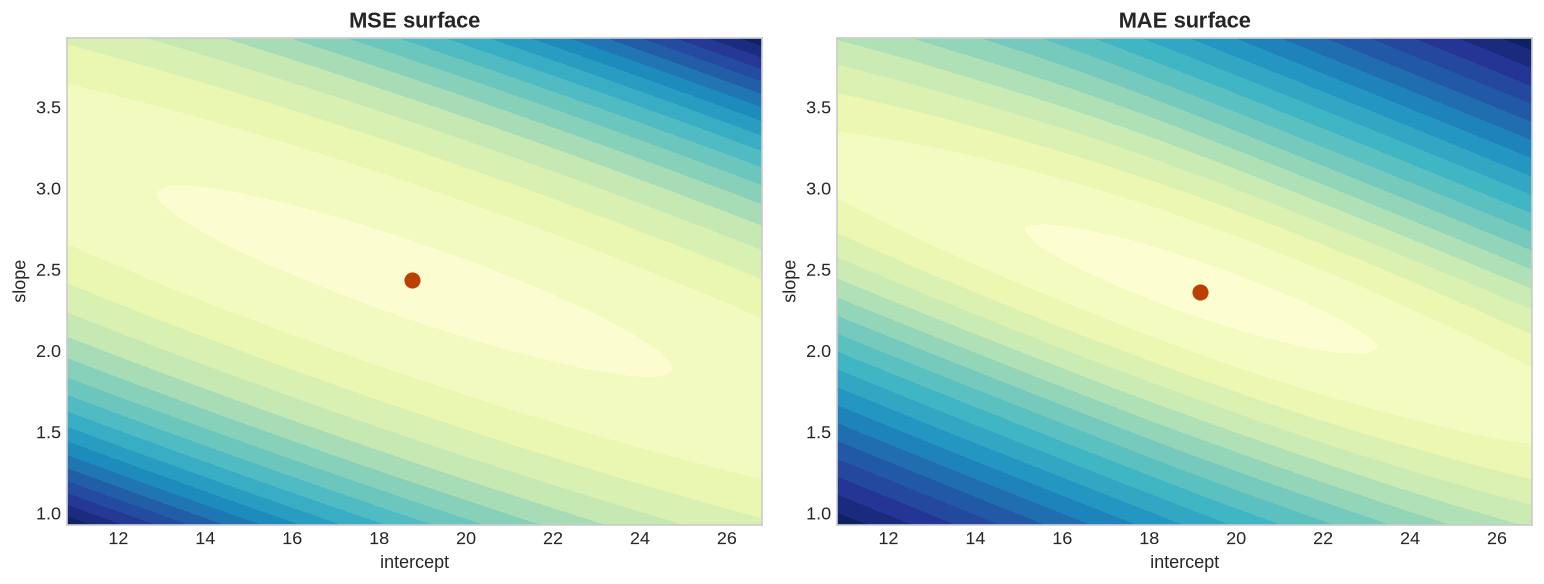

In [27]:
slopes = np.linspace(simple.coef_[0]-1.5, simple.coef_[0]+1.5, 160); intercepts = np.linspace(simple.intercept_-8, simple.intercept_+8,160)
B0,B1 = np.meshgrid(intercepts,slopes); values=x.to_numpy().ravel()
mse=((y.to_numpy()[:,None,None]-(B0[None]+B1[None]*values[:,None,None]))**2).mean(0)
mae=np.abs(y.to_numpy()[:,None,None]-(B0[None]+B1[None]*values[:,None,None])).mean(0)
best_mse=np.unravel_index(mse.argmin(),mse.shape); best_mae=np.unravel_index(mae.argmin(),mae.shape)
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,loss,best,title in [(axes[0],mse,best_mse,"MSE surface"),(axes[1],mae,best_mae,"MAE surface")]:
    ax.contourf(B0,B1,loss,levels=18,cmap="YlGnBu"); ax.scatter(B0[best],B1[best],c=CORAL,s=75)
    ax.set(xlabel="intercept",ylabel="slope",title=title)
plt.tight_layout()

<h2 id="3.-Multiple-regression,-categorical-variables,-interactions,-and-scaling">3. Multiple regression, categorical variables, interactions, and scaling</h2><p>A multiple model holds represented variables fixed. An interaction lets one slope vary with another feature. Scaling changes units of coefficients but not the predictions of an appropriately fitted linear model.</p>

In [28]:
X = data[["distance_km","items","rain_mm"]]
multiple=LinearRegression().fit(X,y)
pd.Series(multiple.coef_,index=X.columns).rename("minutes per one-unit change").to_frame().round(3)

,minutes per one-unit change
distance_km,2.444
items,0.894
rain_mm,0.636


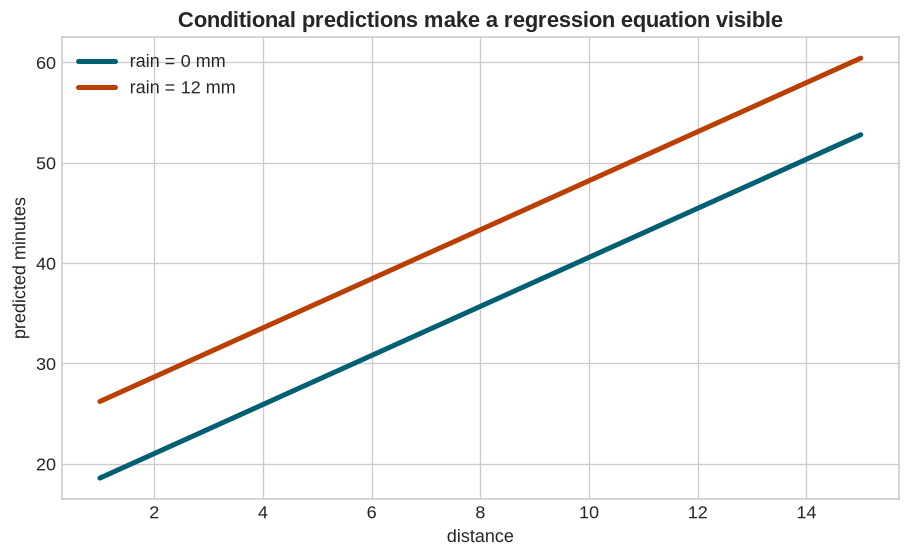

In [29]:
distance=np.linspace(1,15,100)
fig,ax=plt.subplots(figsize=(9,5))
for rain,colour in [(0,TEAL),(12,CORAL)]:
    design=pd.DataFrame({"distance_km":distance,"items":4,"rain_mm":rain})
    ax.plot(distance,multiple.predict(design),c=colour,lw=3,label=f"rain = {rain} mm")
ax.set(xlabel="distance",ylabel="predicted minutes",title="Conditional predictions make a regression equation visible")
ax.legend(); plt.show()

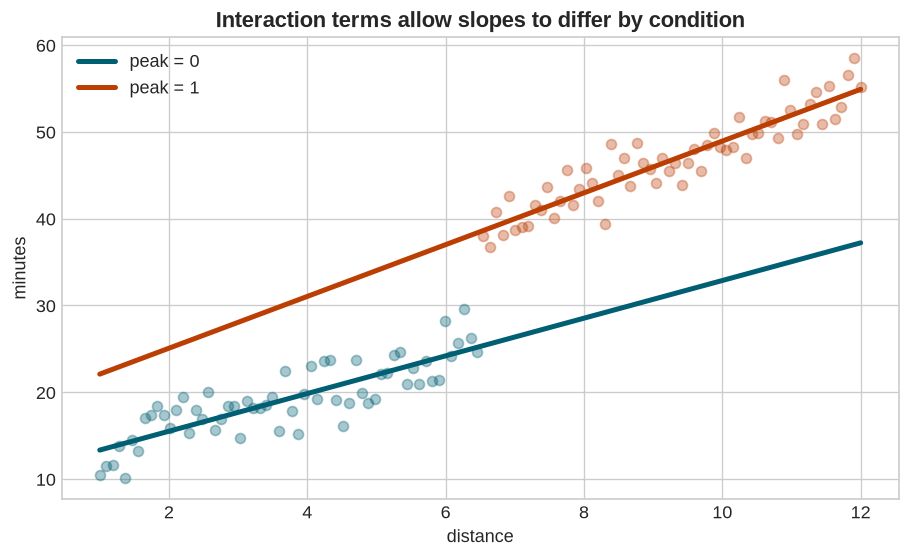

In [30]:
synthetic = pd.DataFrame({"distance":np.linspace(1,12,120),"peak":np.repeat([0,1],60)})
synthetic["minutes"] = 12 + 2*synthetic.distance + 5*synthetic.peak + 1.2*synthetic.distance*synthetic.peak + np.random.default_rng(8).normal(0,2,len(synthetic))
interaction = LinearRegression().fit(np.c_[synthetic.distance,synthetic.peak,synthetic.distance*synthetic.peak],synthetic.minutes)
fig,ax=plt.subplots(figsize=(9,5))
for peak,colour in [(0,TEAL),(1,CORAL)]:
    d=np.linspace(1,12,100); pred=interaction.predict(np.c_[d,np.full(100,peak),d*peak])
    ax.scatter(synthetic.loc[synthetic.peak==peak,"distance"],synthetic.loc[synthetic.peak==peak,"minutes"],alpha=.35,c=colour)
    ax.plot(d,pred,c=colour,lw=3,label=f"peak = {peak}")
ax.set(xlabel="distance",ylabel="minutes",title="Interaction terms allow slopes to differ by condition")
ax.legend(); plt.show()

<h2 id="4.-Leverage,-influence,-collinearity,-and-metrics">4. Leverage, influence, collinearity, and metrics</h2><p>A high-leverage point has unusual features. An influential point changes the fit substantially. Collinearity makes coefficients unstable because several features contain similar information.</p>

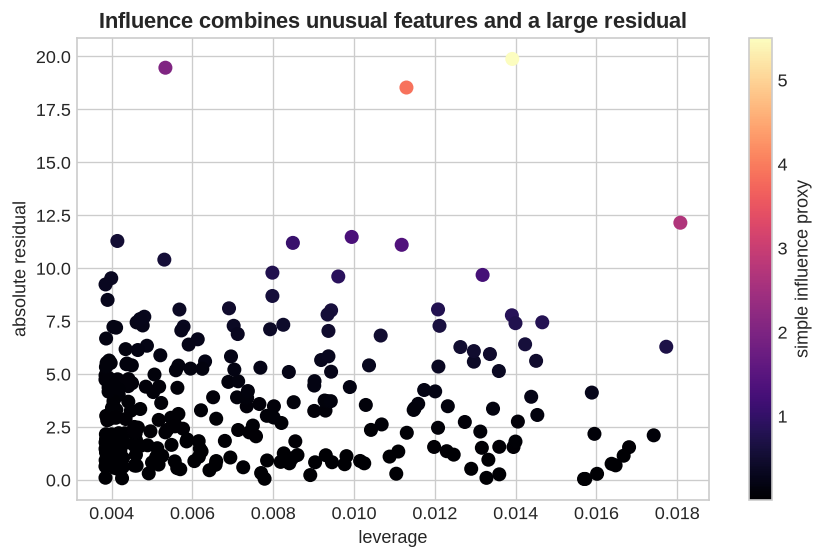

In [31]:
X_design=np.c_[np.ones(len(values)),values]; hat=X_design@np.linalg.inv(X_design.T@X_design)@X_design.T
leverage=np.diag(hat); influence=leverage*residual.to_numpy()**2
fig,ax=plt.subplots(figsize=(8.5,5))
scatter=ax.scatter(leverage,abs(residual),c=influence,cmap="magma",s=55)
ax.set(xlabel="leverage",ylabel="absolute residual",title="Influence combines unusual features and a large residual")
fig.colorbar(scatter,ax=ax,label="simple influence proxy"); plt.show()

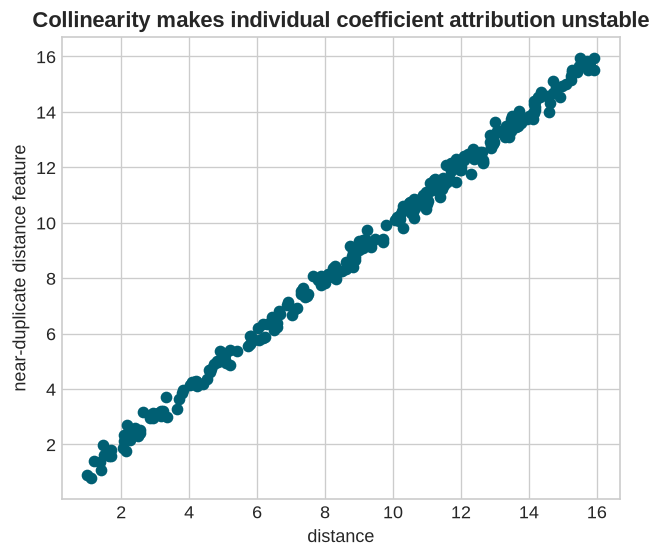

In [32]:
correlated=np.c_[values, values+np.random.default_rng(11).normal(0,.25,len(values))]
fig,ax=plt.subplots(figsize=(6,5)); ax.scatter(correlated[:,0],correlated[:,1],c=TEAL)
ax.set(xlabel="distance",ylabel="near-duplicate distance feature",title="Collinearity makes individual coefficient attribution unstable")
plt.show()

<h2 id="5.-Ridge,-lasso,-regularization-paths,-and-tree-regression">5. Ridge, lasso, regularization paths, and tree regression</h2><p>Ridge shrinks coefficients smoothly. Lasso can set some coefficients to zero. A regression tree predicts a local mean inside a partition rather than one global linear equation.</p>

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=301)
models={"linear":LinearRegression(),"ridge":make_pipeline(StandardScaler(),Ridge(alpha=2)),"lasso":make_pipeline(StandardScaler(),Lasso(alpha=.3)),"tree":DecisionTreeRegressor(max_depth=4,min_samples_leaf=8,random_state=301)}
rows=[]
for name,model in models.items():
    model.fit(X_train,y_train); pred=model.predict(X_test)
    rows.append((name,mean_absolute_error(y_test,pred),mean_squared_error(y_test,pred)**.5))
pd.DataFrame(rows,columns=["model","MAE","RMSE"]).set_index("model").round(2)

,MAE,RMSE
model,,
linear,2.59,3.72
ridge,2.57,3.70
lasso,2.60,3.76
tree,3.75,5.04


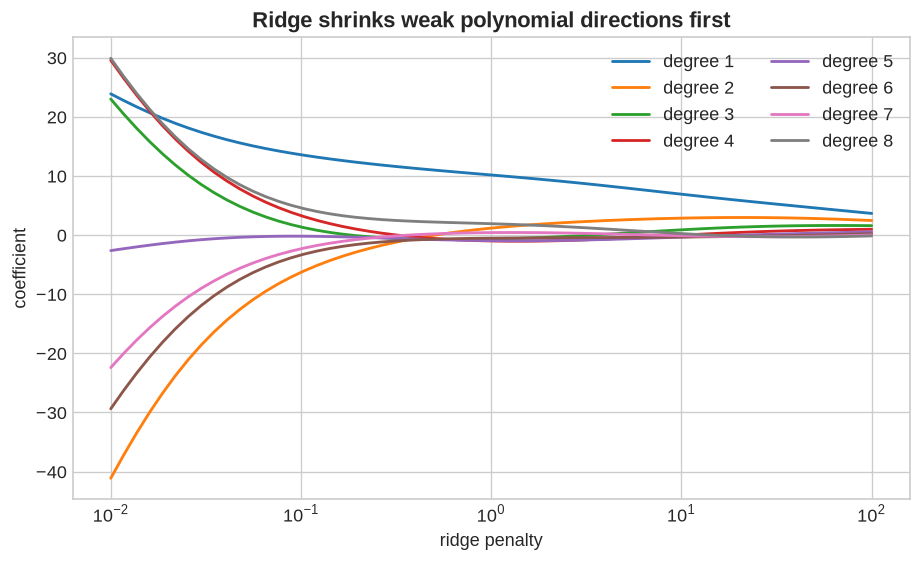

In [34]:
# High-degree powers are on incompatible scales. Standardising first makes the
# penalty interpretable across coefficients and avoids an ill-conditioned system.
poly_raw = PolynomialFeatures(8, include_bias=False).fit_transform(values.reshape(-1, 1))
poly = StandardScaler().fit_transform(poly_raw)
alphas = np.logspace(-2, 2, 60)
path = np.array([Ridge(alpha=a, solver="svd").fit(poly, y).coef_ for a in alphas])
fig,ax=plt.subplots(figsize=(9,5))
for i in range(path.shape[1]): ax.semilogx(alphas,path[:,i],lw=1.7,label=f"degree {i+1}")
ax.set(xlabel="ridge penalty",ylabel="coefficient",title="Ridge shrinks weak polynomial directions first")
ax.legend(ncol=2); plt.show()

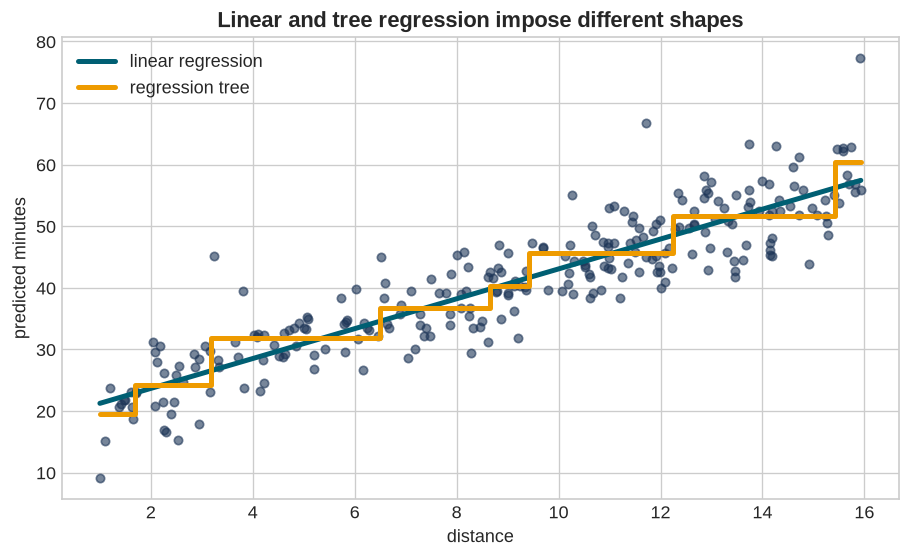

In [35]:
tree_line=DecisionTreeRegressor(max_depth=3,min_samples_leaf=10,random_state=301).fit(x,y)
fig,ax=plt.subplots(figsize=(9,5)); ax.scatter(x,y,c=INK,s=25,alpha=.6)
ax.plot(grid,simple.predict(pd.DataFrame({"distance_km": grid})),c=TEAL,lw=3,label="linear regression")
ax.step(grid,tree_line.predict(pd.DataFrame({"distance_km": grid})),c=GOLD,lw=3,where="mid",label="regression tree")
ax.set(xlabel="distance",ylabel="predicted minutes",title="Linear and tree regression impose different shapes")
ax.legend(); plt.show()

<h2 id="Check-your-understanding">Check your understanding</h2><ol>
<li>Why does MSE react more strongly to a 30-minute residual than MAE?</li>
<li>What does a residual plot reveal that MAE alone cannot?</li>
<li>Why is a conditional coefficient not automatically causal?</li>
<li>How do ridge and lasso differ?</li>
<li>Why can a regression tree fit nonlinearity but extrapolate poorly?</li>
</ol>

<h2 id="Applied-regression-lab:-held-out-estimates-on-a-real-dataset">Applied regression lab: held-out estimates on a real dataset</h2><p>The diabetes study dataset lets us repeat the regression workflow on observations not constructed for this course. The values are standardised baseline measures; the target is disease progression one year later. This is a teaching example, not a clinical model.</p>

In [36]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True).frame
diabetes[["bmi", "bp", "s5", "target"]].head(8)

,bmi,bp,s5,target
0,0.061696,0.021872,0.019907,151.0
1,-0.051474,-0.026328,-0.068332,75.0
2,0.044451,-0.005670,0.002861,141.0
3,-0.011595,-0.036656,0.022688,206.0
4,-0.036385,0.021872,-0.031988,135.0
5,-0.040696,-0.019442,-0.041176,97.0
6,-0.047163,-0.015999,-0.062917,138.0
7,-0.001895,0.066629,-0.035816,63.0


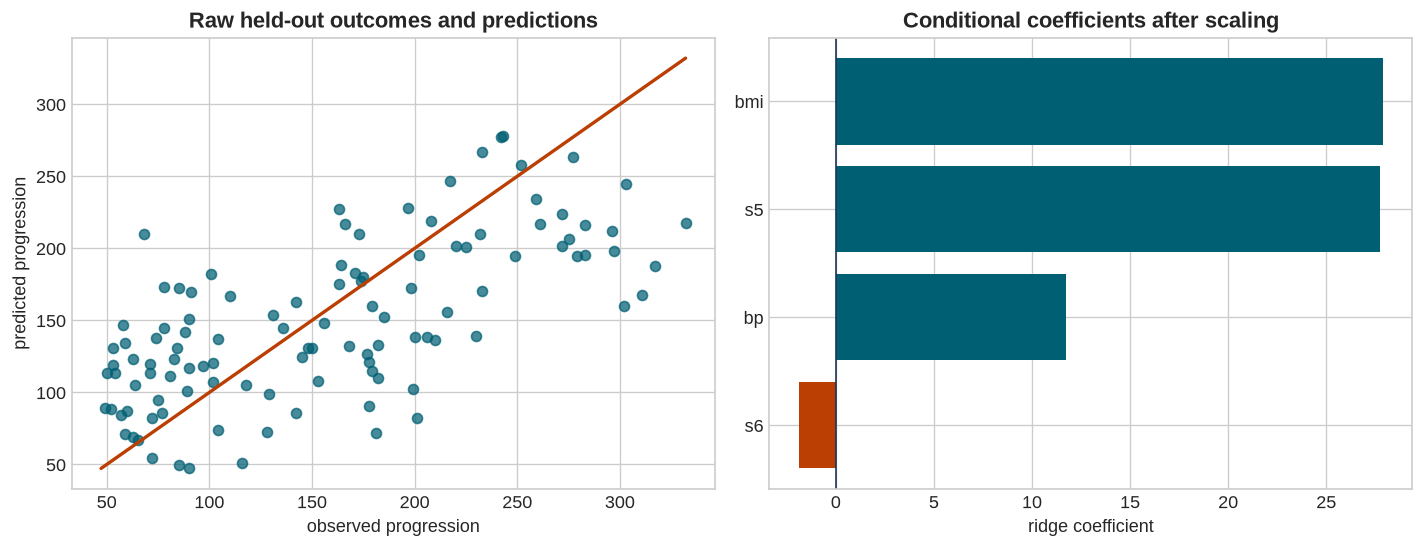

In [37]:
features = ["bmi", "bp", "s5", "s6"]
X_train, X_test, y_train, y_test = train_test_split(diabetes[features], diabetes.target, test_size=.25, random_state=301)
case_model = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(X_train, y_train)
case_prediction = case_model.predict(X_test)
coefs = pd.Series(case_model.named_steps["ridge"].coef_, index=features).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].scatter(y_test, case_prediction, color=TEAL, alpha=.72)
limits = [min(y_test.min(), case_prediction.min()), max(y_test.max(), case_prediction.max())]
axes[0].plot(limits, limits, color=CORAL, lw=2)
axes[0].set(title="Raw held-out outcomes and predictions", xlabel="observed progression", ylabel="predicted progression")
axes[1].barh(coefs.index, coefs.values, color=np.where(coefs.values >= 0, TEAL, CORAL))
axes[1].axvline(0, color=INK, lw=1)
axes[1].set(title="Conditional coefficients after scaling", xlabel="ridge coefficient")
plt.tight_layout()

<p>The left panel evaluates a prediction task; the right panel describes the fitted equation. Neither panel proves that changing a feature causes the target to change.</p>

## A loss landscape in three dimensions

We will predict the **flavanoids measurement of a wine from its total phenols**. These are observed chemical measurements from the Wine Recognition dataset. One row represents one wine sample. The original class label is deliberately excluded from this regression task.

First inspect the recorded measurements. We use only a training subset to build the landscape. Standardising its input and target makes the geometry readable; the displayed parameters and MSE are therefore in standardised units.

,total_phenols,flavanoids
0,2.80,3.06
1,2.65,2.76
2,2.80,3.24
3,3.85,3.49
4,2.80,2.69
5,3.27,3.39
6,2.50,2.52
7,2.60,2.51
8,2.80,2.98
9,2.98,3.15


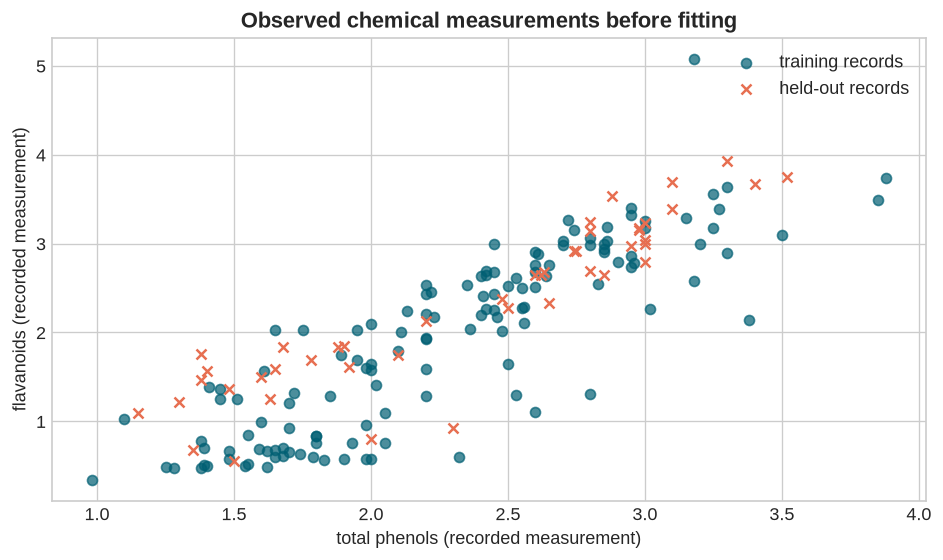

In [38]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display
wine_loss = load_wine(as_frame=True).data[['total_phenols', 'flavanoids']]
display(wine_loss.head(10))
loss_train, loss_test = train_test_split(wine_loss, test_size=.25, random_state=301)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(loss_train.total_phenols, loss_train.flavanoids, label='training records', color='#005F73', alpha=.7)
ax.scatter(loss_test.total_phenols, loss_test.flavanoids, label='held-out records', color='#E76F51', marker='x')
ax.set(xlabel='total phenols (recorded measurement)', ylabel='flavanoids (recorded measurement)', title='Observed chemical measurements before fitting')
ax.legend(); plt.tight_layout(); plt.show()

### Every height comes from prediction errors on these rows

Our candidate equation is $\hat z_y=b+wz_x$. For each parameter pair, predict every training outcome, subtract the recorded standardised target, square each residual, and average. That mean is the vertical height $J(b,w)$.

The table below makes this calculation visible for $b=-1.5,w=-1$. The surface repeats exactly this calculation over a grid of candidate equations. A point on the surface represents an entire fitted rule, not an individual wine.

,z input,z observed,z prediction,residual,squared residual
0,1.195,1.233,-2.695,-3.928,15.426
1,-1.639,-1.455,0.139,1.593,2.539
2,0.075,-1.325,-1.575,-0.249,0.062
3,1.113,1.462,-2.613,-4.074,16.599
4,-1.424,-0.539,-0.076,0.463,0.215
5,0.240,0.715,-1.740,-2.455,6.025
6,0.454,0.566,-1.954,-2.519,6.348
7,-1.358,-0.678,-0.142,0.537,0.288


Mean squared error across ALL training rows: 5.9661


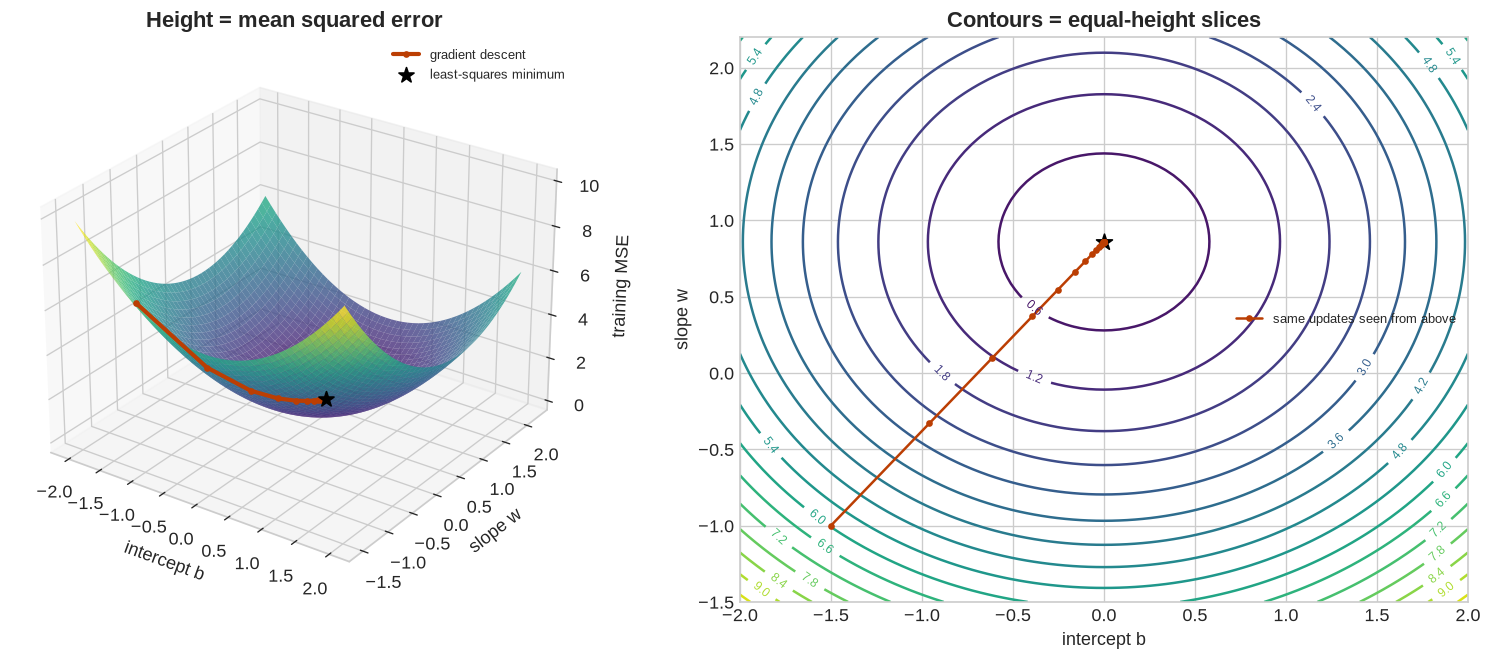

In [39]:
loss_scaler = StandardScaler().fit(loss_train)
loss_z = loss_scaler.transform(loss_train)
zx, zy = loss_z[:, 0], loss_z[:, 1]
design = np.column_stack([np.ones(len(zx)), zx])
theta_start = np.array([-1.5, -1.0])
initial_predictions = design @ theta_start
display(pd.DataFrame({'z input': zx, 'z observed': zy, 'z prediction': initial_predictions,
                      'residual': initial_predictions-zy, 'squared residual': (initial_predictions-zy)**2}).head(8).round(3))
print('Mean squared error across ALL training rows:', np.mean((initial_predictions-zy)**2).round(4))
intercepts = np.linspace(-2, 2, 95)
slopes = np.linspace(-1.5, 2.2, 95)
B, W = np.meshgrid(intercepts, slopes)
residual_grid = B[..., None] + W[..., None]*zx - zy
J = np.mean(residual_grid**2, axis=-1)
theta_opt = np.linalg.lstsq(design, zy, rcond=None)[0]
def mse_at(theta):
    return np.mean((design @ np.asarray(theta)-zy)**2)
def descend(rate=.18, steps=24):
    theta = theta_start.copy()
    history = [theta.copy()]
    for _ in range(steps):
        gradient = 2*design.T @ (design @ theta-zy)/len(zy)
        theta -= rate*gradient
        history.append(theta.copy())
    return np.asarray(history)
trajectory = descend()
heights = np.array([mse_at(t) for t in trajectory])
fig = plt.figure(figsize=(13, 5.4), layout='constrained')
ax3 = fig.add_subplot(121, projection='3d', computed_zorder=False)
surface = ax3.plot_surface(B, W, J, cmap='viridis', alpha=.78, linewidth=0, rasterized=True)
ax3.plot(trajectory[:,0], trajectory[:,1], heights, 'o-', color='#BB3E03', lw=2.5, markersize=3, label='gradient descent', zorder=10)
ax3.scatter(*theta_opt, mse_at(theta_opt), color='black', marker='*', s=90, label='least-squares minimum', zorder=11)
ax3.set(xlabel='intercept b', ylabel='slope w', zlabel='training MSE', title='Height = mean squared error')
ax3.view_init(elev=27, azim=-55); ax3.legend(fontsize=8)
ax2 = fig.add_subplot(122)
contour = ax2.contour(B, W, J, levels=15, cmap='viridis')
ax2.clabel(contour, fontsize=7)
ax2.plot(trajectory[:,0], trajectory[:,1], 'o-', color='#BB3E03', ms=3, label='same updates seen from above')
ax2.scatter(*theta_opt, marker='*', color='black', s=100)
ax2.set(xlabel='intercept b', ylabel='slope w', title='Contours = equal-height slices')
ax2.legend(fontsize=8); plt.show()

### The moving point changes the regression equation

Now return to the observations. Each coloured line below is one selected point from the descent path. The data stays fixed while the intercept and slope change. The curve on the right reports the same training MSE shown as height in the 3D view.

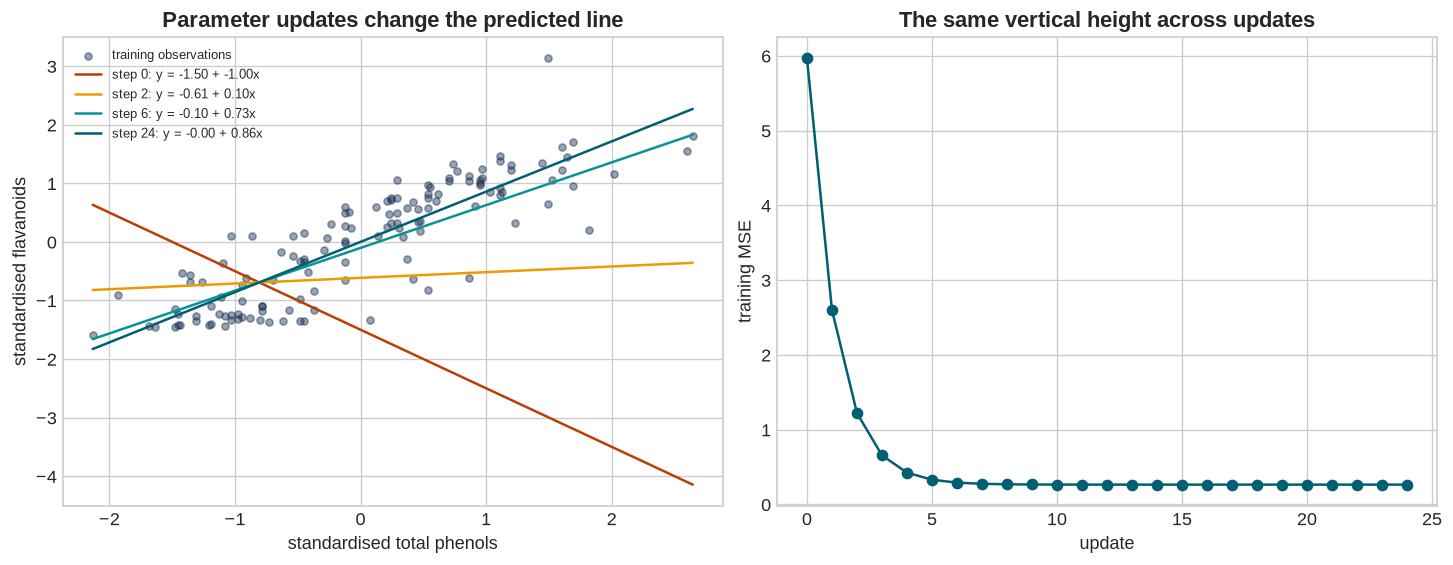

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout='constrained')
axes[0].scatter(zx, zy, c='#1D3557', s=18, alpha=.45, label='training observations')
line_x = np.linspace(zx.min(), zx.max(), 150)
for step, colour in zip([0, 2, 6, 24], ['#BB3E03', '#EE9B00', '#0A9396', '#005F73']):
    b, w = trajectory[step]
    axes[0].plot(line_x, b+w*line_x, color=colour, label=f'step {step}: y = {b:.2f} + {w:.2f}x')
axes[0].set(xlabel='standardised total phenols', ylabel='standardised flavanoids', title='Parameter updates change the predicted line')
axes[0].legend(fontsize=8)
axes[1].plot(np.arange(len(heights)), heights, 'o-', color='#005F73')
axes[1].set(xlabel='update', ylabel='training MSE', title='The same vertical height across updates')
plt.show()

### Changing the loss changes the landscape and fitted line

Use the same raw records and parameter grid. Absolute loss weights a residual in proportion to its magnitude. Squared loss grows faster. Huber loss is quadratic near zero and linear beyond $\delta=1$. Compare shapes **within** each plot: their vertical scales are different.

The minima marked here are numerical solutions of the three stated objectives. Their equations appear over the same training observations in the next plot.

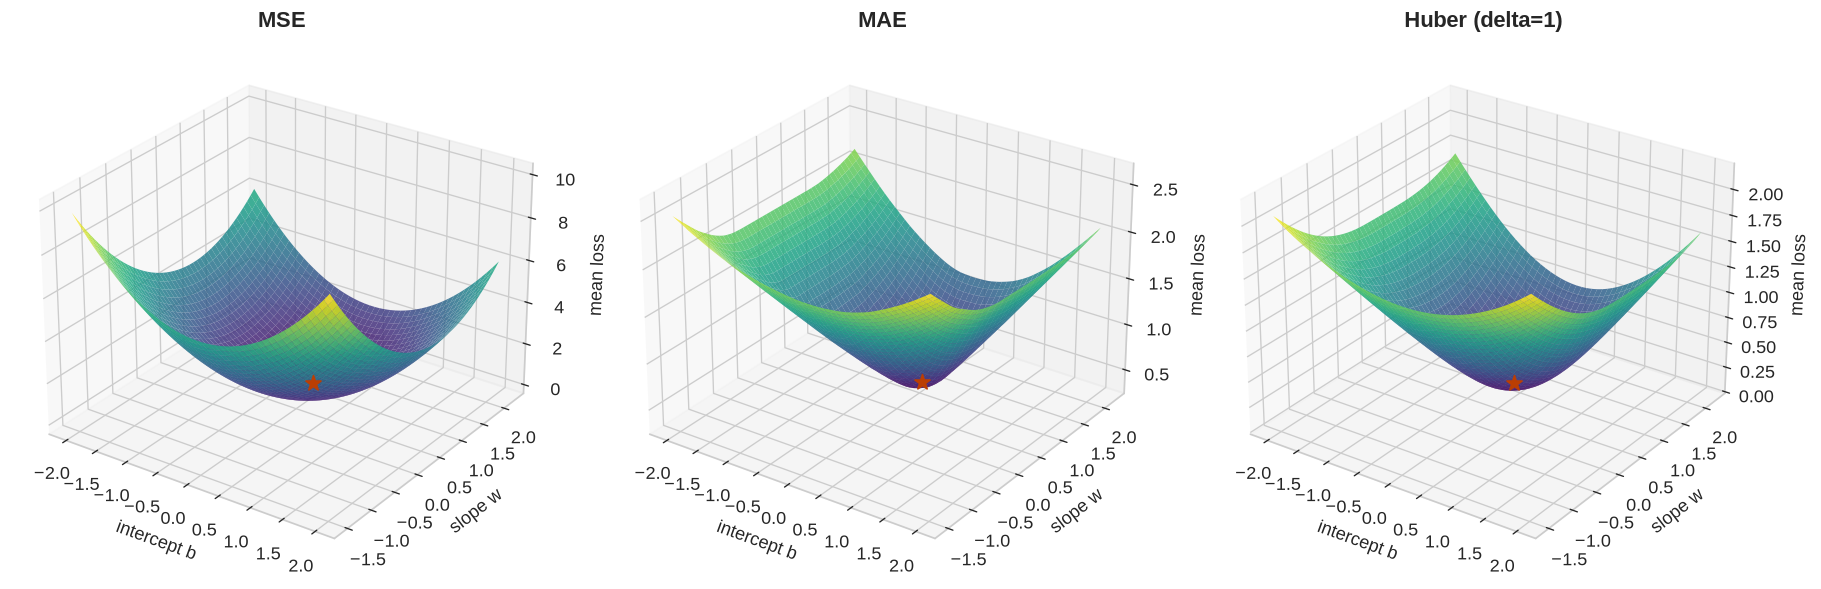

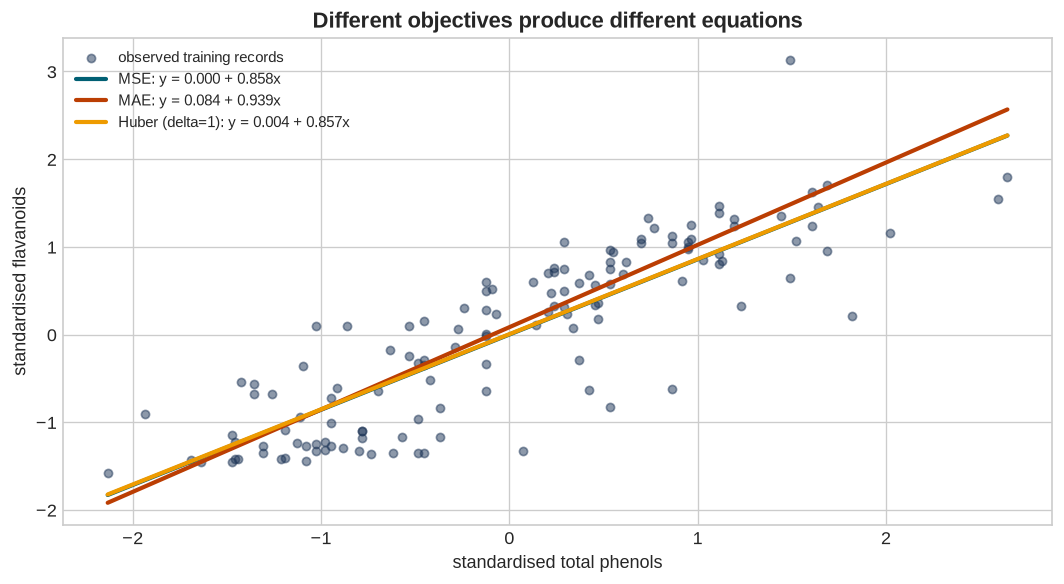

In [41]:
from scipy.optimize import minimize
from sklearn.linear_model import QuantileRegressor
absolute_grid = np.abs(residual_grid)
surfaces = {'MSE': J, 'MAE': absolute_grid.mean(axis=-1),
            'Huber (delta=1)': np.where(absolute_grid <= 1, .5*residual_grid**2, absolute_grid-.5).mean(axis=-1)}
def huber_value(theta):
    e = design @ theta - zy
    return np.where(np.abs(e)<=1, .5*e**2, np.abs(e)-.5).mean()
median_model = QuantileRegressor(quantile=.5, alpha=0, solver='highs').fit(zx[:,None], zy)
huber_fit = minimize(huber_value, theta_opt, method='BFGS', tol=1e-8)
solutions = {'MSE': theta_opt, 'MAE': np.array([median_model.intercept_, median_model.coef_[0]]), 'Huber (delta=1)': huber_fit.x}
fig = plt.figure(figsize=(15, 4.8), layout='constrained')
for i, (name, heights_grid) in enumerate(surfaces.items(), 1):
    ax = fig.add_subplot(1, 3, i, projection='3d', computed_zorder=False)
    ax.plot_surface(B, W, heights_grid, cmap='viridis', alpha=.85, linewidth=0, rasterized=True)
    sol = solutions[name]
    val = {'MSE': mse_at, 'MAE': lambda t: np.abs(design@t-zy).mean(), 'Huber (delta=1)': huber_value}[name](sol)
    ax.scatter(*sol, val, marker='*', c='#BB3E03', s=90, zorder=11)
    ax.set(xlabel='intercept b', ylabel='slope w', zlabel='mean loss', title=name)
    ax.view_init(27, -55)
plt.show()
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(zx, zy, color='#1D3557', alpha=.5, s=24, label='observed training records')
for (name, sol), colour in zip(solutions.items(), ['#005F73', '#BB3E03', '#EE9B00']):
    ax.plot(line_x, sol[0]+sol[1]*line_x, lw=2.5, color=colour, label=f'{name}: y = {sol[0]:.3f} + {sol[1]:.3f}x')
ax.set(xlabel='standardised total phenols', ylabel='standardised flavanoids', title='Different objectives produce different equations')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

### Learning rate and curvature explain the path

For this standardised linear model, the Hessian is $H=2X^TX/n$. Gradient descent converges for $0<\eta<2/\lambda_{\max}(H)$. This bound belongs to this quadratic objective; it is not a universal learning-rate rule.

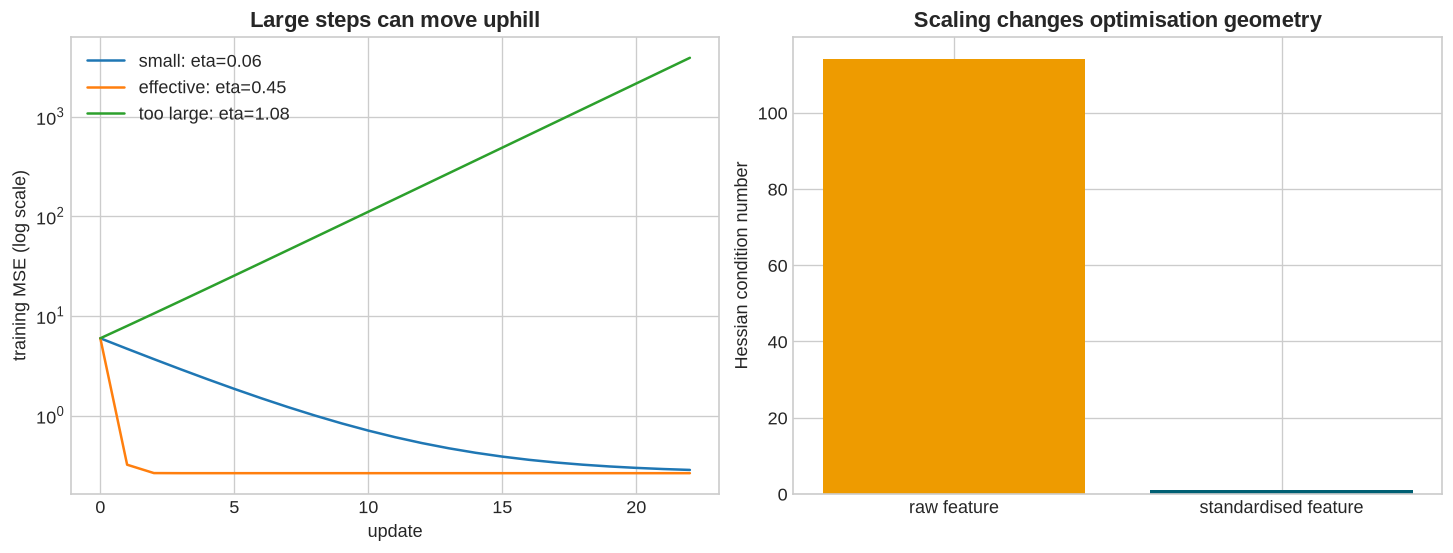

,model,held-out MSE
0,training-mean baseline,0.9696
1,fitted least squares,0.2230


In [42]:
H = 2*design.T@design/len(zy)
rate_bound = 2/np.linalg.eigvalsh(H).max()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for rate, name in [(rate_bound*.06, 'small'), (rate_bound*.45, 'effective'), (rate_bound*1.08, 'too large')]:
    path_rate = descend(rate, steps=22)
    axes[0].semilogy([mse_at(t) for t in path_rate], label=f'{name}: eta={rate:.2f}')
axes[0].set(xlabel='update', ylabel='training MSE (log scale)', title='Large steps can move uphill'); axes[0].legend()
raw_design = np.column_stack([np.ones(len(loss_train)), loss_train.total_phenols])
raw_H = 2*raw_design.T@raw_design/len(loss_train)
axes[1].bar(['raw feature', 'standardised feature'], [np.linalg.cond(raw_H), np.linalg.cond(H)], color=['#EE9B00','#005F73'])
axes[1].set(ylabel='Hessian condition number', title='Scaling changes optimisation geometry')
plt.show()
test_z = loss_scaler.transform(loss_test)
test_prediction = theta_opt[0] + theta_opt[1]*test_z[:,0]
baseline_prediction = np.zeros(len(test_z))
display(pd.DataFrame({'model':['training-mean baseline','fitted least squares'],
                      'held-out MSE':[np.mean((test_z[:,1]-baseline_prediction)**2), np.mean((test_z[:,1]-test_prediction)**2)]}).round(4))

The minimum of the training surface answers an optimisation question. The held-out comparison answers a generalisation question. Neither is a causal estimate. **Class exercise:** predict what changes in the 3D landscape, line plot, and held-out error if the largest observed residual is doubled. Then test your prediction using a copy of the training data.